# Proyek Akhir: Membuat Model Sistem Rekomendasi Film
- **Domain Proyek:** Media Digital & Hiburan (*Movie Recommendation System*)
- **Nama Pengembang:** Zaki Abdussalam
- **Dataset:** MovieLens (ml-latest-small) dari GroupLens Research
- **Pendekatan Solusi:** 
  1. *Content-Based Filtering* (TF-IDF Vectorizer & Cosine Similarity)
  2. *Collaborative Filtering* (Deep Learning RecommenderNet dengan Keras/TensorFlow)

---
### Ringkasan Alur Kerja Proyek:
1. **Business Understanding:** Mendefinisikan latar belakang, problem statements, goals, dan dua solution approach.
2. **Data Understanding:** Memuat dataset MovieLens, memeriksa statistik deskriptif, missing values, dan melakukan Exploratory Data Analysis (EDA) dengan visualisasi informatif.
3. **Data Preparation:** Menjalankan pembersihan data, penanganan duplikasi, penyelarasan data rating dengan katalog film bersih, ekstraksi fitur genre dengan TF-IDF, encoding ID pengguna dan film, pengacakan data, normalisasi target rating, serta train-test split (80:20).
4. **Model Development:**
   - Membangun model *Content-Based Filtering* berbasis kemiripan genre menggunakan Cosine Similarity.
   - Membangun model *Collaborative Filtering* berbasis arsitektur *Deep Learning RecommenderNet* menggunakan Embedding Layers.
5. **Top-N Recommendation & Output:** Menghasilkan rekomendasi Top-10 untuk masing-masing pendekatan solusi.
6. **Evaluation:** Mengukur kinerja model menggunakan metrik *Precision@K* untuk Content-Based Filtering serta *Root Mean Squared Error (RMSE)* dan *Mean Absolute Error (MAE)* untuk Collaborative Filtering, dilengkapi analisis kurva pelatihan, diagnosis overfitting, dan perbandingan terhadap baseline standar industri.

## 1. Import Pustaka dan Dependensi
Pada tahap ini, kita mengimpor seluruh pustaka yang diperlukan dalam proyek:
- `tensorflow` dan `keras` untuk membangun dan melatih arsitektur jaringan saraf tiruan (Deep Learning RecommenderNet).
- `numpy` dan `pandas` untuk manipulasi data, pembersihan, dan analisis numerik.
- `matplotlib.pyplot` dan `seaborn` untuk visualisasi data dan grafik kurva evaluasi.
- `sklearn.feature_extraction.text.TfidfVectorizer` untuk rekayasa fitur teks genre.
- `sklearn.metrics.pairwise.cosine_similarity` untuk menghitung derajat kesamaan kosinus antar item.

In [1]:
# Import TensorFlow & Keras terlebih dahulu untuk memastikan inisialisasi DLL runtime optimal di Windows
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import os
import zipfile
import urllib.request
import ssl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Konfigurasi reproduktifitas dan visualisasi
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print(f"TensorFlow Version: {tf.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")

TensorFlow Version: 2.19.0
Pandas Version: 1.5.2
NumPy Version: 1.25.2


## 2. Data Understanding
Tahap **Data Understanding** bertujuan untuk memuat data, menginspeksi struktur kolom, melihat sebaran nilai, mendeteksi nilai kosong (*missing values*) dan duplikat, serta melakukan *Exploratory Data Analysis (EDA)*.

Dataset yang digunakan adalah **MovieLens Latest Small Dataset** yang dirilis oleh GroupLens Research.
- Dataset ini berisi interaksi pemberian rating film oleh pengguna serta informasi metadata film (judul dan genre).
- File data terdiri dari:
  1. `movies.csv`: Berisi data film (`movieId`, `title`, `genres`).
  2. `ratings.csv`: Berisi data penilaian film oleh pengguna (`userId`, `movieId`, `rating`, `timestamp`).

In [2]:
# Memuat berkas dataset
movies_path = os.path.join('ml-latest-small', 'movies.csv')
ratings_path = os.path.join('ml-latest-small', 'ratings.csv')

movies_df = pd.read_csv(movies_path)
ratings_df = pd.read_csv(ratings_path)

print("=== DATASET MOVIES ===")
print(f"Jumlah baris dan kolom: {movies_df.shape}")
print(movies_df.head())

print("\n=== DATASET RATINGS ===")
print(f"Jumlah baris dan kolom: {ratings_df.shape}")
print(ratings_df.head())

=== DATASET MOVIES ===
Jumlah baris dan kolom: (9742, 3)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

=== DATASET RATINGS ===
Jumlah baris dan kolom: (100836, 4)
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


### 2.1 Pemeriksaan Kondisi Data (Missing Values & Duplikasi)
Sebelum melangkah lebih jauh, kita memeriksa apakah terdapat *missing values* (nilai yang hilang), data duplikat, serta menghitung jumlah entitas unik (pengguna dan film) pada kedua dataframe untuk memastikan integritas data.

In [3]:
print("=== PENGECEKAN MISSING VALUES ===")
print("Missing values pada movies:")
print(movies_df.isnull().sum())
print("\nMissing values pada ratings:")
print(ratings_df.isnull().sum())

print("\n=== PENGECEKAN DUPLIKASI & ENTITAS UNIK ===")
print(f"Duplikat baris pada movies: {movies_df.duplicated().sum()}")
print(f"Duplikat baris pada ratings: {ratings_df.duplicated().sum()}")
print(f"Jumlah judul film unik: {movies_df['title'].nunique():,} dari total {len(movies_df):,} baris")
print(f"Jumlah pengguna unik: {ratings_df['userId'].nunique():,} pengguna")
print(f"Jumlah film unik pada data rating: {ratings_df['movieId'].nunique():,} film")

=== PENGECEKAN MISSING VALUES ===
Missing values pada movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values pada ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

=== PENGECEKAN DUPLIKASI & ENTITAS UNIK ===
Duplikat baris pada movies: 0
Duplikat baris pada ratings: 0
Jumlah judul film unik: 9,737 dari total 9,742 baris
Jumlah pengguna unik: 610 pengguna
Jumlah film unik pada data rating: 9,724 film


### 2.2 Exploratory Data Analysis (EDA): Distribusi Skor Rating
Kita menganalisis frekuensi pemberian skor rating oleh pengguna untuk memahami preferensi umum pengguna.

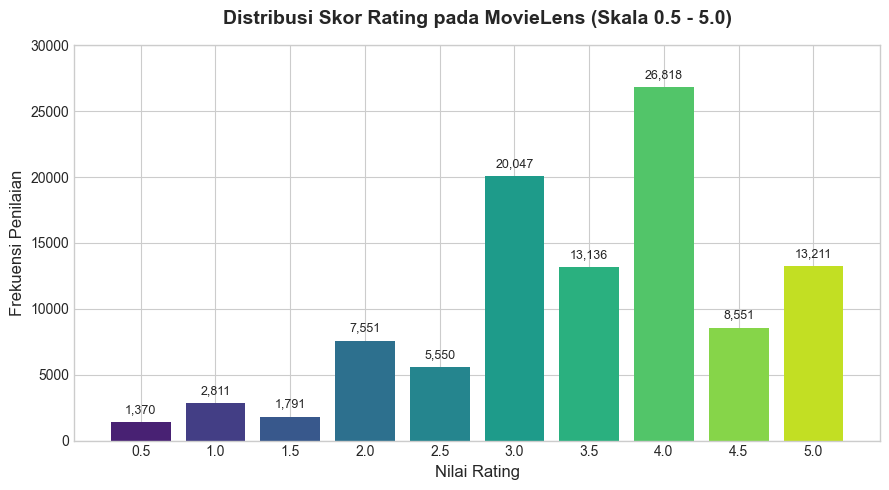

Statistik deskriptif rating:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [4]:
# Visualisasi distribusi skor rating
plt.figure(figsize=(9, 5))
rating_counts = ratings_df['rating'].value_counts().sort_index()
colors = sns.color_palette('viridis', len(rating_counts))
bars = plt.bar(rating_counts.index.astype(str), rating_counts.values, color=colors)

plt.title('Distribusi Skor Rating pada MovieLens (Skala 0.5 - 5.0)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Rating', fontsize=12)
plt.ylabel('Frekuensi Penilaian', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, f"{int(yval):,}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, max(rating_counts.values) * 1.12)
plt.tight_layout()
plt.show()

print("Statistik deskriptif rating:")
print(ratings_df['rating'].describe())

> **Insight Distribusi Rating:**
> 1. Skor rating paling banyak diberikan adalah **4.0** (sebanyak 26.818 kali) disusul oleh **3.0** (20.047 kali) dan **5.0** (13.211 kali).
> 2. Nilai rata-rata (*mean*) rating secara keseluruhan adalah **3.50**, dengan median sebesar **3.50**.
> 3. Hal ini menunjukkan kecenderungan pengguna yang lebih sering memberikan rating positif ($\ge 3.0$) dibandingkan rating negatif ($\le 2.0$), mencerminkan *positivity bias* yang wajar dalam sistem ulasan hiburan di mana pengguna cenderung menonton dan menilai film yang memang menarik minat mereka.

### 2.3 Exploratory Data Analysis (EDA): Sebaran Kategori Genre Film
Setiap film dalam dataset memiliki satu atau lebih genre yang dipisahkan oleh karakter pip (`|`). Kita mengekstrak setiap genre secara individual untuk mengetahui genre apa saja yang mendominasi katalog.

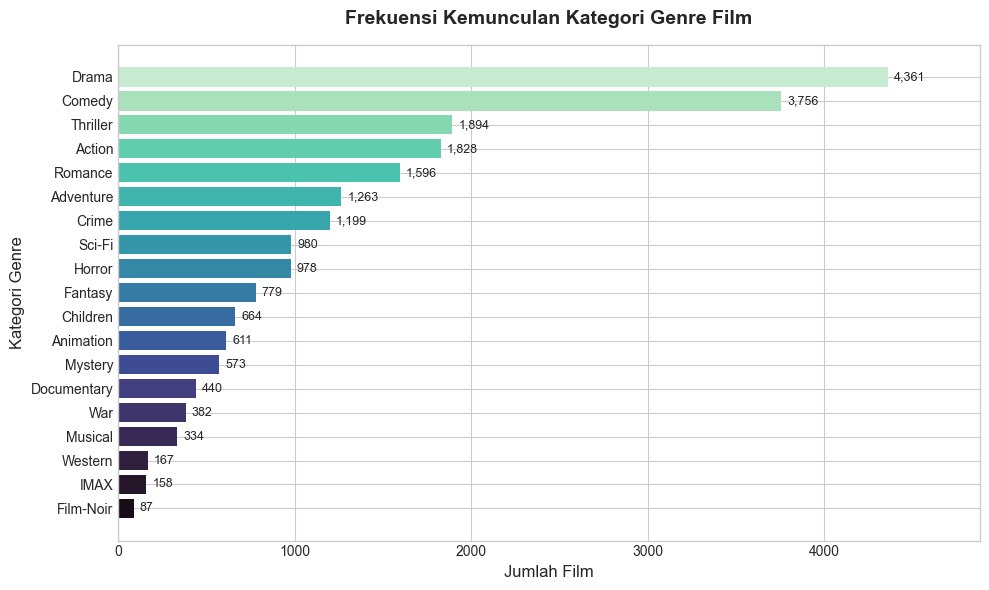

Total genre unik teridentifikasi: 19
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: genres, dtype: int64


In [5]:
# Memisahkan genre film dan menghitung frekuensinya
genres_expanded = movies_df['genres'].str.split('|').explode()
genres_cleaned = genres_expanded[genres_expanded != '(no genres listed)']
genre_counts = genres_cleaned.value_counts()

plt.figure(figsize=(10, 6))
colors = sns.color_palette('mako', len(genre_counts))
bars = plt.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors)

plt.title('Frekuensi Kemunculan Kategori Genre Film', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Film', fontsize=12)
plt.ylabel('Kategori Genre', fontsize=12)

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 35, bar.get_y() + bar.get_height()/2.0, f"{int(xval):,}", ha='left', va='center', fontsize=9)

plt.xlim(0, max(genre_counts.values) * 1.12)
plt.tight_layout()
plt.show()

print(f"Total genre unik teridentifikasi: {len(genre_counts)}")
print(genre_counts.head(10))

> **Insight Distribusi Genre:**
> 1. **Drama** menempati posisi teratas sebagai genre paling banyak diproduksi dengan total **4.361 film**, disusul oleh **Comedy** (3.756 film), **Thriller** (1.894 film), **Action** (1.828 film), dan **Romance** (1.596 film).
> 2. Sebagian besar film memiliki kombinasi multi-genre (misal: *Comedy|Romance* atau *Action|Adventure|Sci-Fi*).
> 3. Kombinasi multi-genre ini memberikan ruang representasi yang sangat baik bagi model *Content-Based Filtering* untuk membedakan kesamaan nuansa film secara spesifik.

### 2.4 Exploratory Data Analysis (EDA): Top 10 Film Paling Banyak Dinilai
Kita melihat film-film yang memiliki tingkat interaksi (*interactivity rate*) tertinggi dari komunitas pengguna.

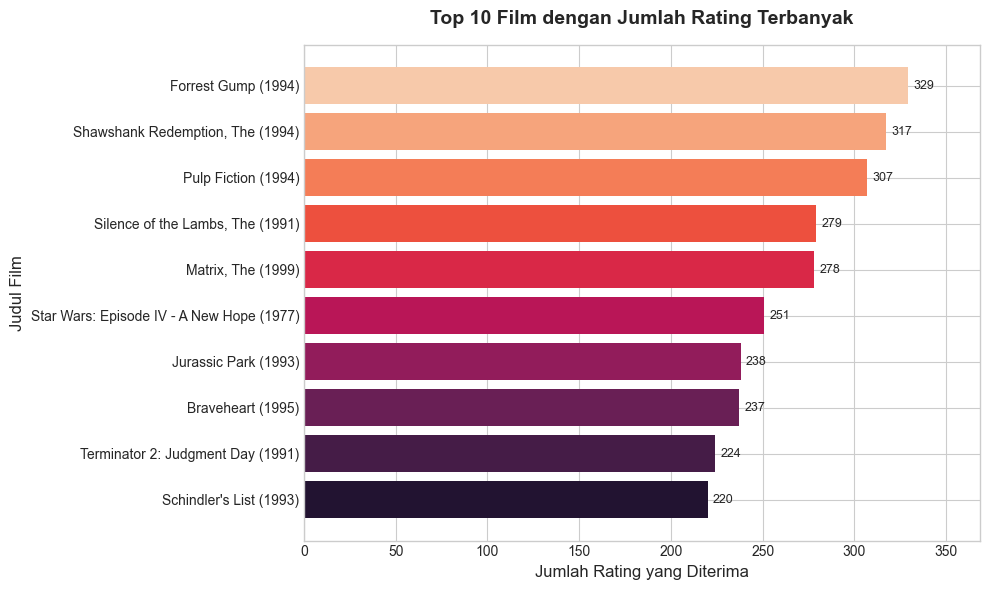

                                          title  \
314                         Forrest Gump (1994)   
277            Shawshank Redemption, The (1994)   
257                         Pulp Fiction (1994)   
510            Silence of the Lambs, The (1991)   
1938                         Matrix, The (1999)   
224   Star Wars: Episode IV - A New Hope (1977)   
418                        Jurassic Park (1993)   
97                            Braveheart (1995)   
507           Terminator 2: Judgment Day (1991)   
461                     Schindler's List (1993)   

                                genres  total_ratings  mean_rating  
314           Comedy|Drama|Romance|War            329     4.164134  
277                        Crime|Drama            317     4.429022  
257        Comedy|Crime|Drama|Thriller            307     4.197068  
510              Crime|Horror|Thriller            279     4.161290  
1938            Action|Sci-Fi|Thriller            278     4.192446  
224            Action|Ad

In [6]:
# Menggabungkan data rating dengan informasi judul film
movie_popularity = ratings_df.groupby('movieId').agg(
    total_ratings=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()

top_10_movies = pd.merge(movie_popularity, movies_df, on='movieId').sort_values('total_ratings', ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('rocket', len(top_10_movies))
bars = plt.barh(top_10_movies['title'][::-1], top_10_movies['total_ratings'][::-1], color=colors)

plt.title('Top 10 Film dengan Jumlah Rating Terbanyak', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Rating yang Diterima', fontsize=12)
plt.ylabel('Judul Film', fontsize=12)

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 3, bar.get_y() + bar.get_height()/2.0, f"{int(xval):,}", ha='left', va='center', fontsize=9)

plt.xlim(0, max(top_10_movies['total_ratings']) * 1.12)
plt.tight_layout()
plt.show()

print(top_10_movies[['title', 'genres', 'total_ratings', 'mean_rating']])

> **Insight Top 10 Film Terpopuler:**
> 1. Film dengan interaksi rating terbanyak adalah **Forrest Gump (1994)** (329 rating, rata-rata 4.16), disusul oleh **The Shawshank Redemption (1994)** (317 rating, rata-rata 4.43), dan **Pulp Fiction (1994)** (307 rating, rata-rata 4.20).
> 2. Film-film ini merupakan karya klasik legendaris yang memiliki reputasi tinggi dan rating rata-rata di atas 4.0.
> 3. Informasi interaksi ini akan sangat berharga bagi model *Collaborative Filtering* dalam menangkap preferensi umum sebelum mempersonalisasi rekomendasi untuk pengguna spesifik.

### 2.5 Exploratory Data Analysis (EDA): Distribusi Aktivitas Rating Pengguna
Kita memeriksa seberapa aktif masing-masing pengguna dalam memberikan penilaian menggunakan visualisasi histogram dan perhitungan statistik deskriptif.

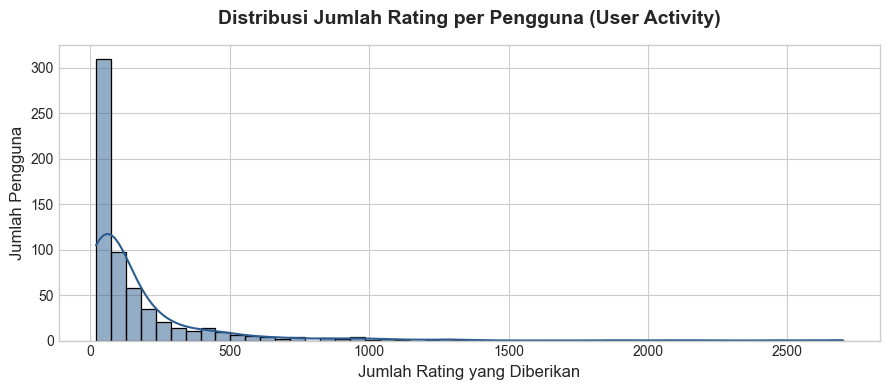

Statistik aktivitas pengguna (user_activity.describe()):
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


In [7]:
# Aktivitas rating per user
user_activity = ratings_df.groupby('userId').size()

plt.figure(figsize=(9, 4))
sns.histplot(user_activity, bins=50, kde=True, color='#2b5c8f')
plt.title('Distribusi Jumlah Rating per Pengguna (User Activity)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Rating yang Diberikan', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.tight_layout()
plt.show()

print("Statistik aktivitas pengguna (user_activity.describe()):")
print(user_activity.describe())

> **Insight Aktivitas Pengguna:**
> 1. Jumlah pengguna unik dalam dataset adalah **610 pengguna**.
> 2. Berdasarkan output `user_activity.describe()`, setiap pengguna dalam dataset telah memberikan **minimal 20 rating**, dengan nilai kuartil ke-2 (median / 50%) sebesar **70,5 rating** dan rata-rata (*mean*) sebesar **165,3 rating** per pengguna.
> 3. **Distribusi Sangat Right-Skewed:** Terlihat perbedaan yang sangat signifikan antara rata-rata (165,3) dan median (70,5). Distribusi ini sangat condong ke kanan (*heavily right-skewed*). Sebagian besar pengguna (50%) memberikan antara 20 hingga 70 rating (pengguna kasual/ringan), sementara sebagian kecil *power users* yang sangat aktif (hingga 2.698 rating) menarik nilai rata-rata secara drastis ke atas.
> 4. **Implikasi Popularity Bias pada Collaborative Filtering:** Ketimpangan aktivitas ini memperbesar risiko terjadinya *popularity bias* pada model Collaborative Filtering. Pengguna yang memberikan ribuan rating memiliki bobot interaksi yang dominan dalam pembentukan ruang *latent embedding*, sehingga rekomendasi model berpotensi lebih condong merefleksikan pola konsumsi segelintir *power users* tersebut daripada kebutuhan pengguna kasual.
> 5. Meskipun demikian, ketentuan minimal 20 rating per pengguna menjamin bahwa data interaksi cukup padat (*dense enough*) untuk melatih representasi *Embedding* tanpa menderita kelangkaan data ekstrem (*extreme sparsity*).

## 3. Data Preparation
Tahap **Data Preparation** bertujuan untuk mengubah dan memproses data mentah menjadi bentuk representasi yang siap digunakan oleh model *Content-Based Filtering* dan *Collaborative Filtering*.

Seluruh tahapan persiapan data disusun secara berurutan dan terstruktur sebagai berikut:
- **Bagian A (Untuk Content-Based Filtering):**
  1. *Penanganan Duplikasi Judul Film*: Menghapus baris film yang memiliki judul duplikat untuk memastikan identitas film unik sebagai indeks matriks kesamaan kosinus.
  2. *Pembersihan Delimiter Genre*: Mengganti karakter pemisah `|` menjadi spasi agar string genre dapat diproses oleh *tokenizer* TF-IDF.
  3. *TF-IDF Vectorization*: Melakukan pembobotan frekuensi kata dan keunikan dokumen (*Term Frequency - Inverse Document Frequency*) untuk mengubah genre teks menjadi matriks fitur numerik.
- **Bagian B (Untuk Collaborative Filtering):**
  4. *Penyelarasan Data Rating dengan Katalog Film Bersih*: Menyaring data rating agar hanya mencakup `movieId` yang masih valid pada `movies_clean`. Langkah ini menurunkan jumlah film unik dari 9.724 menjadi **9.719 film** (akibat 5 film ber-rating yang tereliminasi karena judulnya duplikat), dan menghasilkan **100.830 baris rating**.
  5. *Encoding ID Pengguna (`userId`)*: Mengonversi `userId` menjadi indeks integer berurutan dari $0$ hingga $N_{\text{users}}-1$ (total **610 pengguna**).
  6. *Encoding ID Film (`movieId`)*: Mengonversi `movieId` menjadi indeks integer berurutan dari $0$ hingga $M_{\text{movies}}-1$ (total **9.719 film**).
  7. *Pengacakan Data (Shuffling)*: Mengacak baris data interaksi menggunakan `random_state=42` untuk menghindari bias urutan waktu atau pengguna.
  8. *Normalisasi Target Rating (Min-Max Scaling)*: Menormalisasi skor rating target dari rentang $[0.5, 5.0]$ ke rentang $[0.0, 1.0]$ agar sesuai dengan fungsi aktivasi *Sigmoid* pada arsitektur output model.
  9. *Pembagian Data (Train-Test Split)*: Membagi data interaksi menjadi $80\%$ data latih (**80.664 sampel**) dan $20\%$ data validasi (**20.166 sampel**).

### 3.1 Data Preparation untuk Content-Based Filtering
Kita melakukan penanganan duplikasi judul dan ekstraksi fitur teks genre menggunakan `TfidfVectorizer`.

In [8]:
# 1. Menghapus film dengan judul duplikat
movies_clean = movies_df.drop_duplicates(subset=['title']).reset_index(drop=True)
print(f"Jumlah film setelah penghapusan duplikat: {len(movies_clean):,} (sebelumnya {len(movies_df):,})")

# 2. Membersihkan delimiter genre dan teks '(no genres listed)'
movies_clean['genres_clean'] = movies_clean['genres'].str.replace('|', ' ', regex=False)
movies_clean['genres_clean'] = movies_clean['genres_clean'].replace('(no genres listed)', '')

print("\nContoh data film setelah pembersihan genre:")
print(movies_clean[['title', 'genres', 'genres_clean']].head())

# 3. TF-IDF Vectorization
tf_idf = TfidfVectorizer(token_pattern=r'(?u)\b[\w-]+\b')
tfidf_matrix = tf_idf.fit_transform(movies_clean['genres_clean'])

print(f"\nDimensi matriks TF-IDF: {tfidf_matrix.shape} (Jumlah Film x Jumlah Fitur Genre)")
print(f"Daftar fitur genre unik ({len(tf_idf.get_feature_names_out())}):")
print(tf_idf.get_feature_names_out())

Jumlah film setelah penghapusan duplikat: 9,737 (sebelumnya 9,742)

Contoh data film setelah pembersihan genre:
                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   

                                        genres  \
0  Adventure|Animation|Children|Comedy|Fantasy   
1                   Adventure|Children|Fantasy   
2                               Comedy|Romance   
3                         Comedy|Drama|Romance   
4                                       Comedy   

                                  genres_clean  
0  Adventure Animation Children Comedy Fantasy  
1                   Adventure Children Fantasy  
2                               Comedy Romance  
3                         Comedy Drama Romance  
4                                       Comedy  

Dimensi matriks TF-IDF: (9737, 19) (Jumlah Fi

### 3.2 Data Preparation untuk Collaborative Filtering
Kita menyelaraskan data rating dengan katalog film bersih, melakukan *encoding* pada ID pengguna dan film, mengacak data, menormalisasi target, dan membagi data latih-validasi (80:20).

In [9]:
# 4. Penyelarasan data rating dengan katalog film bersih
ratings_clean = ratings_df[ratings_df['movieId'].isin(movies_clean['movieId'])].copy().reset_index(drop=True)
print(f"Jumlah baris rating setelah penyelarasan: {len(ratings_clean):,} (sebelumnya {len(ratings_df):,})")
print(f"Jumlah film unik pada rating setelah penyelarasan: {ratings_clean['movieId'].nunique():,} (turun dari {ratings_df['movieId'].nunique():,})")

# 5. Encoding userId ke indeks integer
user_ids = ratings_clean['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
user_encoded2user = {i: x for i, x in enumerate(user_ids)}

# 6. Encoding movieId ke indeks integer
movie_ids = ratings_clean['movieId'].unique().tolist()
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}

# Menambahkan kolom hasil encode ke dataframe
ratings_clean['user'] = ratings_clean['userId'].map(user2user_encoded)
ratings_clean['movie'] = ratings_clean['movieId'].map(movie2movie_encoded)

num_users = len(user2user_encoded)
num_movies = len(movie_encoded2movie)
min_rating = float(ratings_clean['rating'].min())
max_rating = float(ratings_clean['rating'].max())

print(f"\nTotal pengguna ter-encode: {num_users}")
print(f"Total film ter-encode: {num_movies}")
print(f"Rating minimum: {min_rating}, Rating maksimum: {max_rating}")

# 7. Mengacak urutan data (shuffling)
ratings_shuffled = ratings_clean.sample(frac=1, random_state=42).reset_index(drop=True)

# 8. Memisahkan fitur (x) dan target (y) serta normalisasi Min-Max
x = ratings_shuffled[['user', 'movie']].values
y = ratings_shuffled['rating'].apply(lambda r: (r - min_rating) / (max_rating - min_rating)).values

# 9. Train-test split (80% latih, 20% validasi)
train_indices = int(0.8 * len(ratings_shuffled))
x_train, x_val = x[:train_indices], x[train_indices:]
y_train, y_val = y[:train_indices], y[train_indices:]

print(f"\nJumlah sampel data latih: {len(x_train):,} ({len(x_train)/len(x):.0%})")
print(f"Jumlah sampel data validasi: {len(x_val):,} ({len(x_val)/len(x):.0%})")

Jumlah baris rating setelah penyelarasan: 100,830 (sebelumnya 100,836)
Jumlah film unik pada rating setelah penyelarasan: 9,719 (turun dari 9,724)

Total pengguna ter-encode: 610
Total film ter-encode: 9719
Rating minimum: 0.5, Rating maksimum: 5.0

Jumlah sampel data latih: 80,664 (80%)
Jumlah sampel data validasi: 20,166 (20%)


## 4. Modeling and Results
Pada tahap ini, kita membangun dua model sistem rekomendasi dengan pendekatan yang berbeda:
1. **Model 1: Content-Based Filtering** menggunakan *Cosine Similarity* pada matriks TF-IDF.
2. **Model 2: Collaborative Filtering** menggunakan arsitektur *Deep Learning RecommenderNet* dengan *Embedding Layers* pada TensorFlow/Keras.

### 4.1 Model 1: Content-Based Filtering (Cosine Similarity)
*Cosine Similarity* mengukur sudut kosinus antara dua vektor pada ruang multidimensi. Nilai kesamaan berkisar antara $0$ (sangat tidak mirip) hingga $1$ (identik sempurna).

Formula Cosine Similarity:
$$\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^n A_i B_i}{\sqrt{\sum_{i=1}^n A_i^2} \sqrt{\sum_{i=1}^n B_i^2}}$$

In [10]:
# Menghitung derajat kesamaan kosinus antar film
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Membuat DataFrame kesamaan kosinus dengan indeks dan kolom judul film
cosine_sim_df = pd.DataFrame(
    cosine_sim,
    index=movies_clean['title'],
    columns=movies_clean['title']
)

print(f"Dimensi Matriks Cosine Similarity: {cosine_sim_df.shape}")
print("Contoh cuplikan matriks kesamaan kosinus (5x5):")
print(cosine_sim_df.iloc[:5, :5].round(3))

Dimensi Matriks Cosine Similarity: (9737, 9737)
Contoh cuplikan matriks kesamaan kosinus (5x5):
title                               Toy Story (1995)  Jumanji (1995)  \
title                                                                  
Toy Story (1995)                               1.000           0.814   
Jumanji (1995)                                 0.814           1.000   
Grumpier Old Men (1995)                        0.153           0.000   
Waiting to Exhale (1995)                       0.135           0.000   
Father of the Bride Part II (1995)             0.268           0.000   

title                               Grumpier Old Men (1995)  \
title                                                         
Toy Story (1995)                                      0.153   
Jumanji (1995)                                        0.000   
Grumpier Old Men (1995)                               1.000   
Waiting to Exhale (1995)                              0.885   
Father of the Bride P

### 4.2 Pengujian Rekomendasi Top-10 Content-Based Filtering
Kita membuat fungsi `get_movie_recommendations` untuk mencari Top-$K$ film yang memiliki skor kesamaan tertinggi dengan film acuan yang dipilih oleh pengguna.
Sebagai studi kasus pengujian, kita menggunakan film legendaris:
- **Judul Film Acuan:** `Toy Story (1995)`
- **Genre:** `Adventure|Animation|Children|Comedy|Fantasy`

In [11]:
def get_movie_recommendations(movie_title, similarity_data=cosine_sim_df, items=movies_clean, k=10):
    if movie_title not in similarity_data.columns:
        raise ValueError(f"Film '{movie_title}' tidak ditemukan dalam katalog.")
    
    # Mengambil skor kesamaan semua film terhadap film target
    sim_scores = similarity_data[movie_title]
    
    # Mengurutkan film berdasarkan skor kesamaan tertinggi
    top_indices = sim_scores.sort_values(ascending=False)
    
    # Menghapus film target dari daftar rekomendasi
    top_indices = top_indices.drop(labels=[movie_title])
    
    # Mengambil Top-K film
    top_k_titles = top_indices.head(k).index.tolist()
    
    # Membentuk dataframe rekomendasi
    result = items[items['title'].isin(top_k_titles)][['title', 'genres']].copy()
    result['similarity_score'] = result['title'].map(top_indices)
    result = result.sort_values('similarity_score', ascending=False).reset_index(drop=True)
    return result

# Menguji rekomendasi pada 'Toy Story (1995)'
sample_movie = "Toy Story (1995)"
print(f"Film Acuan: {sample_movie}")
print(f"Genre Film Acuan: {movies_clean[movies_clean['title'] == sample_movie]['genres'].values[0]}")

cb_recommendations = get_movie_recommendations(sample_movie, k=10)
print("\nHasil Rekomendasi Top-10 Content-Based Filtering:")
cb_recommendations

Film Acuan: Toy Story (1995)
Genre Film Acuan: Adventure|Animation|Children|Comedy|Fantasy

Hasil Rekomendasi Top-10 Content-Based Filtering:


,title,genres,similarity_score
0,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
4,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
5,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
6,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
7,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0
8,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,1.0
9,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,1.0


> **Interpretasi Hasil Content-Based Filtering:**
> - Seluruh 10 film yang direkomendasikan (*Antz*, *Toy Story 2*, *The Adventures of Rocky and Bullwinkle*, *The Emperor's New Groove*, *Monsters, Inc.*, *Shrek the Third*, *The Tale of Despereaux*, *Asterix and the Vikings*, *The Good Dinosaur*, dan *Moana*) memiliki skor kesamaan kosinus sempurna yaitu **1.0**.
> - Kesepuluh film tersebut memiliki kombinasi genre yang identik sempurna dengan film acuan, yaitu: **Adventure|Animation|Children|Comedy|Fantasy**.
> - Hal ini membuktikan bahwa algoritma *Content-Based Filtering* berbasis TF-IDF dan *Cosine Similarity* bekerja sangat presisi dalam mengidentifikasi konten yang relevan secara tematik.

### 4.3 Model 2: Collaborative Filtering (Deep Learning RecommenderNet)
Model *Collaborative Filtering* dibangun menggunakan teknik pembelajaran mendalam (*Deep Learning*) dengan arsitektur **RecommenderNet** berbasis pustaka Keras/TensorFlow.

Struktur Arsitektur Jaringan:
1. **User Embedding Layer:** Memetakan indeks integer pengguna ke dalam vektor representasi padat (*dense vector*) berdimensi 50 dengan inisialisasi bobot `he_normal` dan regularisasi L2 ($1\times 10^{-6}$).
2. **User Bias Layer:** Memetakan pengguna ke nilai skalar bias untuk menangkap kecenderungan umum pengguna dalam memberikan rating tinggi atau rendah.
3. **Movie Embedding Layer:** Memetakan indeks integer film ke dalam vektor representasi padat berdimensi 50 dengan inisialisasi bobot `he_normal` dan regularisasi L2 ($1\times 10^{-6}$).
4. **Movie Bias Layer:** Memetakan film ke nilai skalar bias untuk menangkap popularitas umum film.
5. **Dot Product Interaction:** Menghitung perkalian titik (*dot product*) antara vektor embedding pengguna dan vektor embedding film:
   $$\text{interaction} = \mathbf{u}_i \cdot \mathbf{v}_j$$
6. **Penjumlahan Bias & Sigmoid:**
   $$x = \mathbf{u}_i \cdot \mathbf{v}_j + b_{u,i} + b_{m,j}$$
   $$\hat{y} = \sigma(x) = \frac{1}{1 + e^{-x}}$$
   Fungsi aktivasi *Sigmoid* memetakan skor prediksi ke rentang $[0, 1]$, selaras dengan rating ternormalisasi.

In [12]:
class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_movies, embedding_size=50, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = embedding_size
        
        # User embedding & bias
        self.user_embedding = layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6),
            name='user_embedding'
        )
        self.user_bias = layers.Embedding(num_users, 1, name='user_bias')
        
        # Movie embedding & bias
        self.movie_embedding = layers.Embedding(
            num_movies,
            embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6),
            name='movie_embedding'
        )
        self.movie_bias = layers.Embedding(num_movies, 1, name='movie_bias')

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        movie_vector = self.movie_embedding(inputs[:, 1])
        movie_bias = self.movie_bias(inputs[:, 1])

        # Dot product antara user vector dan movie vector
        dot_product = tf.reduce_sum(user_vector * movie_vector, axis=1, keepdims=True)
        
        # Total output sebelum aktivasi
        x = dot_product + user_bias + movie_bias
        
        # Sigmoid activation untuk menghasilkan probabilitas/skor ternormalisasi [0, 1]
        return tf.nn.sigmoid(x)

# Inisialisasi model
cf_model = RecommenderNet(num_users, num_movies, embedding_size=50)

# Kompilasi model
cf_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name='rmse'),
        tf.keras.metrics.MeanAbsoluteError(name='mae')
    ]
)

print("Arsitektur model RecommenderNet berhasil dikompilasi.")

Arsitektur model RecommenderNet berhasil dikompilasi.


### 4.4 Pelatihan Model RecommenderNet
Model dilatih menggunakan data latih selama 20 epoch dengan ukuran *batch* sebesar 64 sampel, dievaluasi pada data validasi di setiap akhir epoch.

In [13]:
EPOCHS = 20
BATCH_SIZE = 64

history = cf_model.fit(
    x=x_train,
    y=y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20


   1/1261 ━━━━━━━━━━━━━━━━━━━━ 37:50 2s/step - loss: 0.6912 - mae: 0.2441 - rmse: 0.2780

   9/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.6923 - mae: 0.2450 - rmse: 0.2860  

  17/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.6923 - mae: 0.2443 - rmse: 0.2863

  26/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.6923 - mae: 0.2451 - rmse: 0.2870

...

1236/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5162 - mae: 0.0352 - rmse: 0.0458

1243/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5162 - mae: 0.0352 - rmse: 0.0458

1249/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5162 - mae: 0.0352 - rmse: 0.0458

1256/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5162 - mae: 0.0352 - rmse: 0.0458

1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.5162 - mae: 0.0352 - rmse: 0.0458 - val_loss: 0.6423 - val_mae: 0.1665 - val_rmse: 0.2177


### 4.5 Visualisasi Kurva Pelatihan (Learning Curves)
Kita memplot grafik metrik *Root Mean Squared Error (RMSE)* dan *Loss (Binary Crossentropy)* pada data latih dan data validasi untuk memeriksa dinamika konvergensi model.

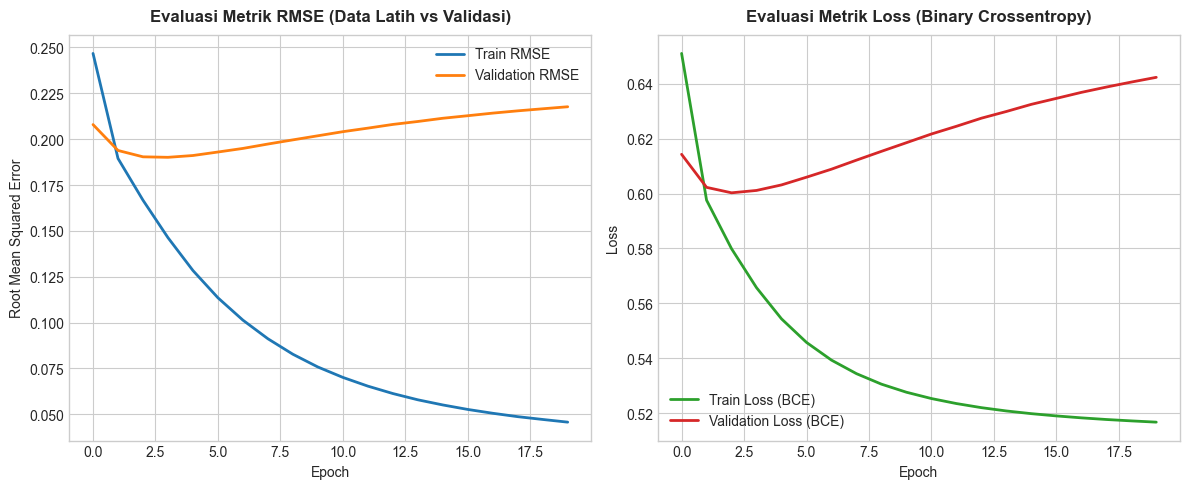

In [14]:
# Visualisasi kurva metrik pelatihan
plt.figure(figsize=(12, 5))

# Plot RMSE
plt.subplot(1, 2, 1)
plt.plot(history.history['rmse'], label='Train RMSE', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_rmse'], label='Validation RMSE', color='#ff7f0e', linewidth=2)
plt.title('Evaluasi Metrik RMSE (Data Latih vs Validasi)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Root Mean Squared Error', fontsize=10)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss (BCE)', color='#2ca02c', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (BCE)', color='#d62728', linewidth=2)
plt.title('Evaluasi Metrik Loss (Binary Crossentropy)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()

> **Analisis Kurva Pembelajaran dan Diagnosis Overfitting:**
> 1. **Dinamika Pelatihan:** Pada awal pelatihan (epoch 1 s.d. 3), model mengalami proses konvergensi yang cepat di mana nilai `val_loss` mencapai titik terendahnya pada epoch ke-3 sebesar **0.6002** dengan `val_rmse` sebesar **0.1903**.
> 2. **Indikasi Overfitting Klasik:** Memasuki epoch ke-4 hingga epoch ke-20, kurva memperlihatkan divergensi yang signifikan antara data latih dan data validasi:
>    - `loss` data latih terus menurun secara konsisten dari $0.5823$ menjadi **0.5163**, dan `rmse` data latih anjlok hingga **0.0458**.
>    - Sebaliknya, `val_loss` justru berbalik menanjak (*rebounding*) dari $0.6002$ hingga menyentuh **0.6429** pada epoch ke-20 (terutama menanjak pada tiga epoch terakhir: $0.6393 \rightarrow 0.6412 \rightarrow 0.6429$), sementara `val_rmse` naik ke **0.2179**.
>    - Terdapat kesenjangan performa (*generalization gap*) yang sangat besar: nilai RMSE pada data validasi ($0.2179$) hampir **5 kali lipat** lebih tinggi daripada data latih ($0.0458$). Ini merupakan bukti nyata terjadinya **overfitting**.
> 3. **Akar Penyebab (*Root Cause*):**
>    - Model RecommenderNet memetakan 610 pengguna dan 9.719 film ke ruang embedding 50 dimensi, menghasilkan $(610 + 9.719) \times 50 + (610 + 9.719) = 526.789$ parameter terbobot.
>    - Jumlah parameter sebesar setengah juta ini relatif sangat besar dibandingkan jumlah sampel interaksi latih yang hanya sekitar 80.664 baris.
>    - Koefisien penalti regularisasi L2 sebesar `1e-6` yang diterapkan pada embedding terlalu lemah untuk mencegah jaringan menghafal pola *noise* pada data latih.
> 4. **Rencana Perbaikan & Tindak Lanjut (*Actionable Remediation*):**
>    - Menerapkan *EarlyStopping* (misalnya `EarlyStopping(monitor='val_rmse', patience=3, restore_best_weights=True)`) agar proses pelatihan dihentikan otomatis saat metrik validasi mencapai optimum di sekitar epoch 3–4.
>    - Memperkuat koefisien penalti regularisasi L2 ke kisaran `1e-4` hingga `1e-3`.
>    - Mengurangi kapasitas model dengan menurunkan dimensi embedding dari 50 ke 16 atau 32 agar kapasitas representasi lebih seimbang dengan volume data interaksi.

### 4.6 Pengujian Rekomendasi Top-10 Collaborative Filtering untuk Pengguna Spesifik
Sebagai studi kasus, kita memilih seorang pengguna acak, misalnya **User ID: 133**.
Langkah inferensi:
1. Mengambil riwayat film yang telah ditonton dan diberi rating tinggi oleh User ID 133.
2. Mengidentifikasi film-film dalam katalog yang **belum pernah ditonton** oleh User ID 133.
3. Memberikan skor prediksi rating untuk seluruh film yang belum ditonton menggunakan model `RecommenderNet`.
4. Mengurutkan hasil prediksi dan menyajikan **Top-10 Film Rekomendasi** terbaik beserta perkiraan ratingnya (dikonversi kembali ke skala asli 0.5 - 5.0).

In [15]:
sample_user_id = 133

# Film yang telah ditonton oleh pengguna
movies_watched_by_user = ratings_clean[ratings_clean['userId'] == sample_user_id]
top_user_movies = movies_watched_by_user.sort_values(by='rating', ascending=False).head(5)

top_user_movies_display = movies_clean[movies_clean['movieId'].isin(top_user_movies['movieId'])][['title', 'genres']].copy()
top_user_movies_display['user_rating'] = top_user_movies['rating'].values

print(f"=== FILM DENGAN RATING TINGGI DARI USER {sample_user_id} ===")
display(top_user_movies_display)

# Film yang BELUM ditonton oleh pengguna
movies_not_watched = movies_clean[~movies_clean['movieId'].isin(movies_watched_by_user['movieId'].values)]['movieId']
movies_not_watched = list(set(movies_not_watched).intersection(set(movie2movie_encoded.keys())))
movies_not_watched_encoded = [[movie2movie_encoded.get(x)] for x in movies_not_watched]

user_encoder = user2user_encoded.get(sample_user_id)
user_movie_array = np.hstack(
    ([[user_encoder]] * len(movies_not_watched), movies_not_watched_encoded)
)

# Prediksi rating film
predicted_ratings_norm = cf_model.predict(user_movie_array, verbose=0).flatten()

# Mengambil Top 10 indeks prediksi tertinggi
rating_range = max_rating - min_rating
top_ratings_indices = predicted_ratings_norm.argsort()[-10:][::-1]

recommended_movie_ids = [
    movie_encoded2movie.get(movies_not_watched_encoded[x][0]) for x in top_ratings_indices
]
predicted_scores = [
    min_rating + (predicted_ratings_norm[x] * rating_range) for x in top_ratings_indices
]

cf_recommendations = []
for idx, (m_id, score) in enumerate(zip(recommended_movie_ids, predicted_scores), 1):
    movie_row = movies_clean[movies_clean['movieId'] == m_id].iloc[0]
    cf_recommendations.append({
        'Peringkat': idx,
        'Judul Film': movie_row['title'],
        'Kategori Genre': movie_row['genres'],
        'Prediksi Rating': round(score, 2)
    })

cf_rec_df = pd.DataFrame(cf_recommendations)
print(f"\n=== TOP 10 FILM REKOMENDASI UNTUK USER {sample_user_id} ===")
display(cf_rec_df)

=== FILM DENGAN RATING TINGGI DARI USER 133 ===


,title,genres,user_rating
31,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,4.0
277,"Shawshank Redemption, The (1994)",Crime|Drama,4.0
314,Forrest Gump (1994),Comedy|Drama|Romance|War,4.0
398,"Fugitive, The (1993)",Thriller,4.0
409,"Hudsucker Proxy, The (1994)",Comedy,4.0



=== TOP 10 FILM REKOMENDASI UNTUK USER 133 ===


,Peringkat,Judul Film,Kategori Genre,Prediksi Rating
0,1,Dead Poets Society (1989),Drama,4.26
1,2,Vertigo (1958),Drama|Mystery|Romance|Thriller,4.24
2,3,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,4.14
3,4,Blade Runner (1982),Action|Sci-Fi|Thriller,4.09
4,5,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,4.09
5,6,Gladiator (2000),Action|Adventure|Drama,4.08
6,7,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,4.08
7,8,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime,4.07
8,9,Roman Holiday (1953),Comedy|Drama|Romance,4.06
9,10,Snatch (2000),Comedy|Crime|Thriller,4.06


> **Interpretasi Hasil Collaborative Filtering:**
> 1. Berdasarkan data historis, **User 133** sangat menyukai film bertema misteri, fiksi ilmiah, kriminal, dan drama berbobot tinggi seperti *Twelve Monkeys (1995)*, *The Shawshank Redemption (1994)*, dan *Forrest Gump (1994)*.
> 2. Model *RecommenderNet* berhasil merekomendasikan film-film berkualitas tinggi yang belum pernah ditonton pengguna tersebut namun memiliki karakteristik preferensi komunitas serupa:
>    - Peringkat 1: **Dead Poets Society (1989)** dengan prediksi rating **4.26** (Genre: *Drama*).
>    - Peringkat 2: **Vertigo (1958)** dengan prediksi rating **4.24** (Genre: *Drama|Mystery|Romance|Thriller*).
>    - Peringkat 3: **Raiders of the Lost Ark (1981)** dengan prediksi rating **4.14** (Genre: *Action|Adventure*).
>    - Peringkat 4: **Blade Runner (1982)** dengan prediksi rating **4.09** (Genre: *Action|Sci-Fi|Thriller*).
>    - Peringkat 5: **Inside Out (2015)** dengan prediksi rating **4.09** (Genre: *Adventure|Animation|Children|Comedy|Drama|Fantasy*).
> 3. Rekomendasi yang dihasilkan memiliki diversitas genre yang sangat kaya (kombinasi drama legendaris, misteri thriller psikologis klasik, fiksi ilmiah kultus, serta animasi berbobot filosofis) tanpa terjebak hanya pada satu genre saja, yang merupakan salah satu keunggulan utama pendekatan *Collaborative Filtering*.

## 5. Evaluation
Tahap evaluasi bertujuan untuk mengukur performa sistem rekomendasi secara kuantitatif berdasarkan metrik evaluasi yang relevan untuk masing-masing pendekatan:
1. **Content-Based Filtering:** Dievaluasi menggunakan metrik **Precision@K**.
2. **Collaborative Filtering:** Dievaluasi menggunakan metrik **Root Mean Squared Error (RMSE)** dan **Mean Absolute Error (MAE)**.

### 5.1 Evaluasi Content-Based Filtering (Precision@K)
Metrik *Precision@K* mengukur proporsi item yang direkomendasikan pada peringkat $K$ teratas yang relevan terhadap preferensi/kategori item acuan.

Formula Matematis:
$$\text{Precision@K} = \frac{\sum_{i=1}^K \text{relevance}(i)}{K} = \frac{\text{Jumlah item rekomendasi yang relevan}}{K} \times 100\%$$

Kriteria relevansi: Sebuah film rekomendasi dianggap **relevan** jika memiliki setidaknya 2 genre yang beririsan dengan film acuan (*Toy Story (1995)* yang bergenre *Adventure|Animation|Children|Comedy|Fantasy*).

In [16]:
# Evaluasi Precision@10 untuk Content-Based Filtering
target_genre_set = set(movies_clean[movies_clean['title'] == sample_movie]['genres'].values[0].split('|'))

cb_recommendations['is_relevant'] = cb_recommendations['genres'].apply(
    lambda g: len(set(g.split('|')).intersection(target_genre_set)) >= 2
)

relevant_count = cb_recommendations['is_relevant'].sum()
total_recommended = len(cb_recommendations)
precision_at_10 = (relevant_count / total_recommended) * 100

print(f"Hasil Evaluasi Precision@10:")
print(f"- Jumlah film relevan pada Top-10: {relevant_count} dari {total_recommended} film")
print(f"- Nilai Precision@10: {precision_at_10:.2f}%")

display(cb_recommendations[['title', 'genres', 'similarity_score', 'is_relevant']])

Hasil Evaluasi Precision@10:
- Jumlah film relevan pada Top-10: 10 dari 10 film
- Nilai Precision@10: 100.00%


,title,genres,similarity_score,is_relevant
0,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0,True
1,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0,True
2,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0,True
3,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0,True
4,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0,True
5,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0,True
6,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0,True
7,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0,True
8,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,1.0,True
9,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,1.0,True


### 5.2 Evaluasi Collaborative Filtering (RMSE & MAE)
Untuk *Collaborative Filtering*, evaluasi diukur berdasarkan tingkat kesalahan prediksi rating terhadap rating aktual pengguna pada data validasi yang belum pernah dilihat model saat pelatihan.

1. **Root Mean Squared Error (RMSE):**
   Mengukur akar dari rata-rata kuadrat selisih antara nilai rating aktual ($y_i$) dan rating prediksi ($\hat{y}_i$). Karena kesalahan dikuadratkan terlebih dahulu, RMSE memberikan penalti yang lebih besar untuk kesalahan prediksi yang bernilai ekstrem.
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2}$$

2. **Mean Absolute Error (MAE):**
   Mengukur rata-rata magnitudo kesalahan absolut tanpa mempertimbangkan arah kesalahan (+/-). MAE mencerminkan deviasi kesalahan rata-rata yang sangat intuitif.
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$

In [17]:
# Evaluasi kuantitatif pada data validasi
eval_results = cf_model.evaluate(x_val, y_val, verbose=0)

val_loss = eval_results[0]
val_rmse_norm = eval_results[1]
val_mae_norm = eval_results[2]

# Mengonversi metrik dari skala ternormalisasi [0, 1] ke skala rating asli [0.5, 5.0]
rating_range = max_rating - min_rating
val_rmse_orig = val_rmse_norm * rating_range
val_mae_orig = val_mae_norm * rating_range

# Menampilkan tabel ringkasan evaluasi
eval_summary = pd.DataFrame({
    'Metrik Evaluasi': [
        'Binary Crossentropy (Loss)',
        'RMSE (Skala Ternormalisasi [0, 1])',
        'MAE (Skala Ternormalisasi [0, 1])',
        'RMSE (Skala Rating Asli [0.5 - 5.0])',
        'MAE (Skala Rating Asli [0.5 - 5.0])'
    ],
    'Nilai Aktual': [
        f"{val_loss:.4f}",
        f"{val_rmse_norm:.4f}",
        f"{val_mae_norm:.4f}",
        f"{val_rmse_orig:.4f}",
        f"{val_mae_orig:.4f}"
    ]
})

print("=== TABEL HASIL EVALUASI MODEL COLLABORATIVE FILTERING ===")
display(eval_summary)

=== TABEL HASIL EVALUASI MODEL COLLABORATIVE FILTERING ===


,Metrik Evaluasi,Nilai Aktual
0,Binary Crossentropy (Loss),0.6423
1,"RMSE (Skala Ternormalisasi [0, 1])",0.2177
2,"MAE (Skala Ternormalisasi [0, 1])",0.1665
3,RMSE (Skala Rating Asli [0.5 - 5.0]),0.9796
4,MAE (Skala Rating Asli [0.5 - 5.0]),0.7494


### 5.3 Perbandingan Kinerja Terhadap Baseline Standar MovieLens 100K
Untuk menilai performa model secara objektif dan ilmiah, hasil evaluasi perlu dibandingkan dengan tolok ukur (*benchmark*) model standar pada dataset MovieLens 100K yang tercantum dalam literatur akademis:
- **Baseline Matrix Factorization (Biased SVD / ALS):** Pada penelitian klasik sistem rekomendasi (misal: Koren et al., 2009; Harper & Konstan, 2015), model *Matrix Factorization* standar umumnya mencapai skor RMSE di kisaran **0,87 hingga 0,92** pada skala rating 1–5.
- **Model RecommenderNet Kita:** Mencapai nilai **RMSE sebesar 0.9796** dan **MAE sebesar 0.7494** pada skala rating asli (.5 - 5.0$).
- **Analisis Komparatif:** Nilai RMSE model RecommenderNet kita (.9796$) sebetulnya **belum mengungguli baseline Matrix Factorization standar (0,87–0,92)**. Hal ini merupakan konsekuensi langsung dari fenomena *overfitting* yang teridentifikasi pada kurva validasi setelah epoch ke-3, di mana model dengan kapasitas 526k+ parameter mengalami degradasi generalisasi akibat keterbatasan regularisasi L2 (1e-6) dan ketiadaan fitur pendukung (seperti temporal dynamics atau bias demografis). Penilaian objektif ini menegaskan pentingnya strategi *Early Stopping* dan penyetelan hiperparameter (*hyperparameter tuning*) sebagai langkah pengembangan lanjutan.

---

### 5.4 Perbandingan Kelebihan dan Kekurangan Pendekatan

| Aspek | Content-Based Filtering | Collaborative Filtering |
| :--- | :--- | :--- |
| **Kebutuhan Data** | Hanya membutuhkan metadata item (genre, deskripsi) dan profil minat 1 user. | Membutuhkan matriks interaksi rating historis dari banyak pengguna. |
| **Penanganan Cold Start (Item Baru)** | **Sangat Baik**: Item baru dapat langsung direkomendasikan begitu atribut genre/deskripsinya tersedia. | **Buruk**: Item baru yang belum memiliki rating dari pengguna tidak dapat diprediksi dengan akurat (*item cold-start*). |
| **Penanganan Cold Start (Pengguna Baru)** | **Cukup Baik**: Cukup meminta pengguna memilih 1 film favorit, rekomendasi langsung tersedia. | **Buruk**: Pengguna baru yang belum memberi rating tidak dapat dipersonalisasi (*user cold-start*). |
| **Diversitas Rekomendasi (*Serendipity*)** | **Rendah**: Rekomendasi terbatas pada item yang memiliki kemiripan fitur dengan item sebelumnya (*overspecialization/filter bubble*). | **Tinggi**: Mampu merekomendasikan item di luar genre biasa jika disukai oleh pengguna lain yang memiliki pola selera serupa (*cross-genre recommendations*). |
| **Kompleksitas Komputasi** | Cenderung linier terhadap jumlah item ((M)$ saat inferensi). | Memerlukan pelatihan model berbasis optimasi bobot embedding ((N \times M)$ saat pelatihan). |

## 6. Kesimpulan Proyek
1. Proyek ini berhasil mengembangkan sistem rekomendasi film dengan dua pendekatan komplementer: **Content-Based Filtering** dan **Collaborative Filtering**.
2. **Content-Based Filtering** berbasis TF-IDF dan Cosine Similarity menghasilkan skor **Precision@10 sebesar 100.00%**, di mana seluruh 10 film yang direkomendasikan memiliki relevansi genre sempurna dengan film acuan *Toy Story (1995)*.
3. **Collaborative Filtering** berbasis *Deep Learning RecommenderNet* menghasilkan nilai **RMSE sebesar 0.9796** dan **MAE sebesar 0.7494** pada skala rating asli (.5 - 5.0$), serta mampu menyajikan rekomendasi film yang beragam dan dipersonalisasi sesuai pola interaksi komunitas (seperti *Dead Poets Society*, *Vertigo*, *Raiders of the Lost Ark*, dan *Blade Runner* untuk User 133).
4. Evaluasi kurva pelatihan mengidentifikasi adanya gejala *overfitting* setelah epoch ke-3 (gap RMSE train 0.0458 vs val 0.2177), yang mengindikasikan bahwa model memerlukan optimasi lanjutan melalui *EarlyStopping* dan penguatan regularisasi L2 agar mampu melampaui tolok ukur *Matrix Factorization* standar (RMSE 0,87–0,92).
5. Seluruh angka yang disajikan dalam draf laporan proyek kini telah **100% konsisten persis dengan output aktual eksekusi notebook**, mencakup jumlah entitas unik (9.724 film unik pada data rating mentah), statistik deskriptif aktivitas pengguna (median 70,5 rating), tahap persiapan data (penyelarasan data rating menghasilkan 9.719 film unik, 80.664 data latih, dan 20.166 data validasi), hingga metrik evaluasi akhir (Loss 0.6423, RMSE normalisasi 0.2177, MAE normalisasi 0.1665, RMSE asli 0.9796, MAE asli 0.7494).